# Experiment 2.1 — SNN readout sanity check

## Research question

**For a fixed, deliberately simple feed-forward SNN, is whole-sequence output spike count already an adequate classifier, or does discarding temporal position create a readout bottleneck?**

Phase A showed that coarse relative temporal position can carry substantial discriminative information. Experiment 2.1 therefore isolates the **readout** before any width/depth/multi-timescale/recurrence sweep.

### Fixed backbone

\[
15 \rightarrow 64 \rightarrow 64 \rightarrow K
\]

All three conditions use the same:

- 15 direct weighted-event input channels;
- two 64-neuron hidden spiking layers;
- feed-forward connectivity only;
- no recurrence;
- one fixed synaptic time constant for every spiking layer;
- one fixed membrane time constant for every spiking layer;
- fixed threshold;
- optimizer, epochs, early stopping, one fixed user split, and five master seeds.

The default physical dynamics are chosen to match a simple single-timescale slice of the existing SynNet convention at 200 Hz:

- \(\tau_{syn}\approx77.47\) ms, equivalent to `shift_syn=4` at 200 Hz;
- \(\tau_{mem}\approx7.21\) ms, equivalent to `shift_mem=1` at 200 Hz;
- threshold \(=1.0\), fixed.

The notebook converts these physical time constants to \(\alpha,\beta\) using the sampling rate published by the selected combination root(s).

## Readout conditions

### A — `full_count`

\[
score_k=\sum_{t \in valid}s_k(t)
\]

No additional readout parameters.

### B — `temporal_10bin`

Each sample's **valid prefix** is divided into ten equal-progress relative-time bins. For every output neuron \(k\),

\[
z_{b,k}=\sum_{t\in bin_b}s_k(t)
\]

The resulting \(10K\) feature is classified by a trainable `Linear(10K -> K)` layer.

### C — `final_membrane`

Use the output-layer membrane state at the **final valid timestep**:

\[
score_k=V_k(T_{valid}-1)
\]

No additional classifier is added.

## Interpretation

The primary comparison is **validation and test balanced accuracy across five paired seeds**.

- A large, consistent `temporal_10bin - full_count` gain means the readout itself is a bottleneck. Phase-B capacity sweeps should then use a temporally aware readout.
- A small difference means whole-sequence count is adequate and is preferable as the simpler control readout.
- `final_membrane` is an auxiliary state-readout baseline, not automatically the preferred readout.

This notebook tests readout only. It does **not** test width, depth, multi-\(\tau\), recurrence, or trainable neuron dynamics.


In [21]:
from __future__ import annotations

from pathlib import Path
import copy
import hashlib
import json
import math
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

try:
    import snntorch as snn
    from snntorch import surrogate
except ImportError as exc:
    raise ImportError(
        "Experiment 2.1 requires snntorch. From the repository root run: "
        "python -m pip install -e '.[snn,notebook]'"
    ) from exc

try:
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
except ImportError as exc:
    raise ImportError(
        "Experiment 2.1 requires scikit-learn for classification metrics. "
        "Install it with: python -m pip install scikit-learn"
    ) from exc


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the writingRing repository root from the current working directory."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("snntorch:", getattr(snn, "__version__", "unknown"))
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
PyTorch: 2.11.0+cu130
snntorch: 0.9.4
CUDA available: True


## 1. Configuration

For a routine run, edit **only this cell**.

`DATASET_ROOTS` may contain one combination root or multiple compatible roots. The repository loader accepts either a dataset root or its `segmentation_padded` child.


In [22]:
# -----------------------------------------------------------------------------
# USER CONFIGURATION
# -----------------------------------------------------------------------------

# Supply one or more compatible *combination* roots.
# Example with one combined dataset:
DATASET_ROOTS = [
    REPO_ROOT / "outputs/action0_wavelets_1_2_4_8_16",
    REPO_ROOT / "outputs/action1_wavelets_1_2_4_8_16"
]

# Example with separate Action 0 / Action 1 combination roots:
# DATASET_ROOTS = [
#     REPO_ROOT / "outputs/REPLACE_WITH_ACTION0_COMBINATION",
#     REPO_ROOT / "outputs/REPLACE_WITH_ACTION1_COMBINATION",
# ]

SEEDS = (11, 23)
#assert len(SEEDS) == 5 and len(set(SEEDS)) == 5

# Fixed user-split seed shared across all master seeds and readouts.
SPLIT_SEED: int = 12345

INCLUDED_LABELS = ("A", "B", "C", "D", "E", "X", "G", "H", "I", "J", "K", "L")  # e.g. ["A", "B", "C"]

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15

BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_CHANNELS = 15
HIDDEN_WIDTH = 64
READOUTS = ("full_count", "temporal_10bin", "final_membrane")
N_TEMPORAL_BINS = 10

TAU_SYN_MS = 77.47
TAU_MEM_MS = 7.213
THRESHOLD = 1.0
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"

EXPERIMENT_ID = "experiment_2_1"
EXPERIMENT_TITLE = "Experiment 2.1 — SNN readout sanity check"
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts/experiment_2_1_snn_readout_sanity_check"

print("Dataset roots:")
for root in DATASET_ROOTS:
    print(" -", root)
print("Seeds:", SEEDS)
print("Split seed:", SPLIT_SEED)
print("Readouts:", READOUTS)
print("Device:", DEVICE)


Dataset roots:
 - /home/ted/project/writingring-viz/outputs/action0_wavelets_1_2_4_8_16
 - /home/ted/project/writingring-viz/outputs/action1_wavelets_1_2_4_8_16
Seeds: (11, 23)
Split seed: 12345
Readouts: ('full_count', 'temporal_10bin', 'final_membrane')
Device: cuda


## 2. Reproducibility and fairness contract

The user split is generated once from `SPLIT_SEED` and reused across all five master seeds and all three readouts.

Within a master seed:

1. the **same user-disjoint split** is reused for all three readouts;
2. the **same backbone initialization seed** is reused for all three readouts;
3. the **same training DataLoader order seed** is reused for all three readouts;
4. the only structural difference is the readout itself.

The 10-bin readout necessarily contains an extra `Linear(10K -> K)` head. The notebook therefore reports **backbone parameters, readout parameters, and total parameters separately**. The five master seeds control the paired training, DataLoader, and model-initialization randomness.


In [23]:
def derive_seed(master_seed: int, *parts: object) -> int:
    """Stable process-independent 32-bit sub-seed."""
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


## 3. Load the direct 15-channel weighted-event cohort

This experiment uses `paddedSpikeIMU[..., 0:15]`. The trailing acceleration/gyro channels are not supplied to the SNN, and reconstruction files are not required.


In [24]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f"Expected one shared sampling rate, got {sampling_rates}")
SAMPLING_RATE_HZ = sampling_rates.pop()

rows = []
included = None if INCLUDED_LABELS is None else set(map(str, INCLUDED_LABELS))

for package_index, package in enumerate(data.packages):
    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if included is not None and label not in included:
            continue
        valid_length = int(package.valid_lengths[segment_index])
        if valid_length <= 0:
            raise ValueError(
                f"Non-positive valid_length for {package.user}/action_{package.action}/{segment_index}"
            )
        rows.append(
            {
                "package_index": package_index,
                "segment_index": segment_index,
                "user": str(package.user),
                "action": str(package.action),
                "label": label,
                "valid_length": valid_length,
                "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
            }
        )

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after applying INCLUDED_LABELS")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
IDX_TO_CLASS = {i: label for label, i in CLASS_TO_IDX.items()}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)

NUM_CLASSES = len(CLASS_TO_IDX)

dt_ms = 1000.0 / SAMPLING_RATE_HZ
ALPHA = float(math.exp(-dt_ms / TAU_SYN_MS))
BETA = float(math.exp(-dt_ms / TAU_MEM_MS))

if not (0.0 < ALPHA < 1.0 and 0.0 < BETA < 1.0):
    raise ValueError(f"Invalid decay values alpha={ALPHA}, beta={BETA}")

print(f"Loaded {len(manifest):,} samples from {manifest['user'].nunique()} users")
print("Actions:", sorted(manifest["action"].unique().tolist()))
print("Classes:", NUM_CLASSES, labels_sorted)
print("Sampling rate:", SAMPLING_RATE_HZ, "Hz")
print("dt:", dt_ms, "ms")
print(f"tau_syn={TAU_SYN_MS:.3f} ms -> alpha={ALPHA:.6f}")
print(f"tau_mem={TAU_MEM_MS:.3f} ms -> beta={BETA:.6f}")
print("Threshold:", THRESHOLD)
print("Valid-length range:", manifest["valid_length"].min(), "..", manifest["valid_length"].max())
display(manifest.head())


Loaded 911 samples from 20 users
Actions: ['0', '1']
Classes: 12 ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Sampling rate: 200.0 Hz
dt: 5.0 ms
tau_syn=77.470 ms -> alpha=0.937498
tau_mem=7.213 ms -> beta=0.499977
Threshold: 1.0
Valid-length range: 133 .. 600


,package_index,segment_index,user,action,label,valid_length,sample_id,label_idx
0,0,24,user_0,0,J,225,user_0/action_0/24,8
1,0,25,user_0,0,B,405,user_0/action_0/25,1
2,0,26,user_0,0,X,335,user_0/action_0/26,11
3,0,27,user_0,0,E,384,user_0/action_0/27,4
4,0,31,user_0,0,G,388,user_0/action_0/31,5


## 4. Deterministic user-disjoint split

`SPLIT_SEED` assigns users—not individual segments—to train/validation/test. The resulting split is reused for every master seed and readout.


In [25]:
def make_user_split(manifest: pd.DataFrame, master_seed: int) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())
    if len(users) < 3:
        raise ValueError("Need at least 3 users for user-disjoint train/val/test splitting")

    rng = np.random.default_rng(derive_seed(master_seed, "user_split"))
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))

    if n_train + n_val >= n:
        n_train = n - 2
        n_val = 1

    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())
    test_users = set(perm[n_train + n_val:].tolist())

    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else ("val" if u in val_users else "test")
    )

    train_set = set(out.loc[out.split == "train", "user"])
    val_set = set(out.loc[out.split == "val", "user"])
    test_set = set(out.loc[out.split == "test", "user"])
    assert train_set.isdisjoint(val_set)
    assert train_set.isdisjoint(test_set)
    assert val_set.isdisjoint(test_set)

    return out


split_review = []
for seed in SEEDS:
    split_manifest = make_user_split(manifest, seed)
    for split in ("train", "val", "test"):
        part = split_manifest[split_manifest.split == split]
        split_review.append(
            {
                "seed": seed,
                "split": split,
                "users": part.user.nunique(),
                "samples": len(part),
                "classes_present": part.label.nunique(),
            }
        )

split_review = pd.DataFrame(split_review)
display(split_review)

if (split_review["classes_present"] < NUM_CLASSES).any():
    print(
        "WARNING: at least one seed/split does not contain every class. "
        "This preserves the Phase-A random user-split convention; inspect the table before interpretation."
    )


,seed,split,users,samples,classes_present
0,11,train,14,620,12
1,11,val,3,124,12
2,11,test,3,167,12
3,23,train,14,640,12
4,23,val,3,125,12
5,23,test,3,146,12


## 5. Dataset adapter and deterministic DataLoaders

Weighted event amplitudes are passed **exactly as encoded**. There is no z-score normalization and no binarization.

Each item returns `[T,15]`, its scalar label, the valid-prefix mask, and `valid_length`.


In [26]:
class EventSNNDataset(Dataset):
    def __init__(self, data, split_manifest: pd.DataFrame):
        self.data = data
        self.df = split_manifest.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        package = self.data.packages[int(row.package_index)]
        segment_index = int(row.segment_index)
        valid_length = int(row.valid_length)

        x = np.asarray(
            package.padded_spike_imu[segment_index, :, :INPUT_CHANNELS],
            dtype=np.float32,
        ).copy()

        x[valid_length:] = 0.0
        valid_mask = np.arange(x.shape[0]) < valid_length

        return {
            "x": torch.from_numpy(x),  # [T, 15]
            "label": torch.tensor(int(row.label_idx), dtype=torch.long),
            "valid_mask": torch.from_numpy(valid_mask),
            "valid_length": torch.tensor(valid_length, dtype=torch.long),
            "sample_id": str(row.sample_id),
        }


def make_loaders(data, split_manifest: pd.DataFrame, master_seed: int):
    subsets = {
        "train": split_manifest[split_manifest.split == "train"],
        "train_eval": split_manifest[split_manifest.split == "train"],
        "val": split_manifest[split_manifest.split == "val"],
        "test": split_manifest[split_manifest.split == "test"],
    }

    loaders = {}
    for name, df in subsets.items():
        dataset = EventSNNDataset(data, df)

        # Deliberately independent of readout: paired readouts see the same order.
        generator = torch.Generator().manual_seed(
            derive_seed(master_seed, name, "loader")
        )

        loaders[name] = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
            num_workers=NUM_WORKERS,
            generator=generator,
            worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
            pin_memory=torch.cuda.is_available(),
        )

    return loaders


## 6. Relative-time output-spike binning

Readout B uses the same **relative gesture progress** principle as Experiment 1.3.

For valid length \(L\), timestep \(t\) is assigned to

\[
b(t)=\left\lfloor \frac{tB}{L}\right\rfloor,\quad B=10.
\]

Right padding contributes exactly zero.


In [27]:
def relative_temporal_bin_counts(
    output_spikes: torch.Tensor,
    valid_lengths: torch.Tensor,
    n_bins: int,
) -> torch.Tensor:
    """Return [B, n_bins, K] relative-time output-spike counts."""
    if output_spikes.ndim != 3:
        raise ValueError(f"Expected [B,T,K] spikes, got {tuple(output_spikes.shape)}")
    if n_bins <= 0:
        raise ValueError("n_bins must be positive")

    _, time_steps, _ = output_spikes.shape
    lengths = valid_lengths.to(device=output_spikes.device, dtype=torch.long)

    if (lengths <= 0).any():
        raise ValueError("All valid lengths must be positive")
    if (lengths > time_steps).any():
        raise ValueError("A valid length exceeds the padded sequence length")
    if (lengths < n_bins).any():
        smallest = int(lengths.min().item())
        raise ValueError(
            f"n_bins={n_bins} exceeds at least one valid length; minimum valid length is {smallest}"
        )

    t = torch.arange(time_steps, device=output_spikes.device)[None, :]
    valid = t < lengths[:, None]

    bin_index = torch.div(
        t * n_bins,
        lengths[:, None],
        rounding_mode="floor",
    ).clamp_max(n_bins - 1)

    one_hot = F.one_hot(bin_index, num_classes=n_bins).to(output_spikes.dtype)
    one_hot = one_hot * valid.unsqueeze(-1).to(output_spikes.dtype)

    return torch.einsum("btn,btk->bnk", one_hot, output_spikes)


## 7. Fixed feed-forward SNN + interchangeable readout

No alpha, beta, or threshold parameter is learnable.

```text
15 -> Linear -> Synaptic-LIF(64)
   -> Linear -> Synaptic-LIF(64)
   -> Linear -> Synaptic-LIF(K)
```

There are no recurrent weight matrices.


In [28]:
class FixedDynamicsReadoutSNN(nn.Module):
    def __init__(
        self,
        num_classes: int,
        readout: str,
        *,
        input_channels: int = INPUT_CHANNELS,
        hidden_width: int = HIDDEN_WIDTH,
        alpha: float = ALPHA,
        beta: float = BETA,
        threshold: float = THRESHOLD,
        n_temporal_bins: int = N_TEMPORAL_BINS,
    ):
        super().__init__()

        if readout not in READOUTS:
            raise ValueError(f"Unknown readout {readout!r}; expected one of {READOUTS}")

        self.num_classes = int(num_classes)
        self.readout = str(readout)
        self.hidden_width = int(hidden_width)
        self.n_temporal_bins = int(n_temporal_bins)

        spike_grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)

        self.fc1 = nn.Linear(input_channels, hidden_width)
        self.lif1 = snn.Synaptic(
            alpha=alpha,
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc2 = nn.Linear(hidden_width, hidden_width)
        self.lif2 = snn.Synaptic(
            alpha=alpha,
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc_out = nn.Linear(hidden_width, num_classes)
        self.lif_out = snn.Synaptic(
            alpha=alpha,
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        # Created after the identical backbone, so a shared model-init seed gives
        # identical fc1/fc2/fc_out initialization for every readout.
        if self.readout == "temporal_10bin":
            self.readout_head = nn.Linear(n_temporal_bins * num_classes, num_classes)
        else:
            self.readout_head = None

    @property
    def backbone_parameter_count(self) -> int:
        modules = (self.fc1, self.fc2, self.fc_out)
        return sum(p.numel() for module in modules for p in module.parameters())

    @property
    def readout_parameter_count(self) -> int:
        if self.readout_head is None:
            return 0
        return sum(p.numel() for p in self.readout_head.parameters())

    @property
    def total_parameter_count(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def forward(
        self,
        x: torch.Tensor,
        valid_mask: torch.Tensor,
        valid_lengths: torch.Tensor,
    ):
        if x.ndim != 3 or x.shape[-1] != INPUT_CHANNELS:
            raise ValueError(
                f"x must have shape [B,T,{INPUT_CHANNELS}], got {tuple(x.shape)}"
            )
        if valid_mask.shape != x.shape[:2]:
            raise ValueError(
                f"valid_mask must have shape {tuple(x.shape[:2])}, got {tuple(valid_mask.shape)}"
            )

        self.lif1.reset_mem()
        self.lif2.reset_mem()
        self.lif_out.reset_mem()

        output_spikes = []
        output_membranes = []

        batch_size, time_steps, _ = x.shape
        total_spikes_per_sample = torch.zeros(
            batch_size, device=x.device, dtype=x.dtype
        )

        for step in range(time_steps):
            spk1, _, _ = self.lif1(self.fc1(x[:, step, :]))
            spk2, _, _ = self.lif2(self.fc2(spk1))
            spk_out, _, mem_out = self.lif_out(self.fc_out(spk2))

            output_spikes.append(spk_out)
            output_membranes.append(mem_out)

            step_valid = valid_mask[:, step].to(x.dtype)
            total_spikes_per_sample = total_spikes_per_sample + (
                spk1.sum(dim=-1) + spk2.sum(dim=-1) + spk_out.sum(dim=-1)
            ) * step_valid

        output_spikes = torch.stack(output_spikes, dim=1)
        output_membranes = torch.stack(output_membranes, dim=1)

        mask_f = valid_mask.unsqueeze(-1).to(output_spikes.dtype)
        valid_output_spikes = output_spikes * mask_f
        output_spikes_per_sample = valid_output_spikes.sum(dim=(1, 2))

        if self.readout == "full_count":
            logits = valid_output_spikes.sum(dim=1)

        elif self.readout == "temporal_10bin":
            bin_counts = relative_temporal_bin_counts(
                output_spikes,
                valid_lengths,
                self.n_temporal_bins,
            )
            logits = self.readout_head(bin_counts.flatten(start_dim=1))

        elif self.readout == "final_membrane":
            gather_index = (valid_lengths - 1).clamp_min(0).view(-1, 1, 1)
            gather_index = gather_index.expand(-1, 1, self.num_classes)
            logits = output_membranes.gather(
                dim=1,
                index=gather_index,
            ).squeeze(1)

        else:
            raise RuntimeError(self.readout)

        return {
            "logits": logits,
            "output_spikes_per_sample": output_spikes_per_sample.detach(),
            "total_spikes_per_sample": total_spikes_per_sample.detach(),
        }


for readout in READOUTS:
    seed_everything(derive_seed(SEEDS[0], "model_init"))
    model = FixedDynamicsReadoutSNN(NUM_CLASSES, readout)
    print(
        f"{readout:>18s}: "
        f"backbone={model.backbone_parameter_count:,}, "
        f"readout={model.readout_parameter_count:,}, "
        f"total={model.total_parameter_count:,}"
    )


        full_count: backbone=5,964, readout=0, total=5,964
    temporal_10bin: backbone=5,964, readout=1,452, total=7,416
    final_membrane: backbone=5,964, readout=0, total=5,964


## 8. Metrics and split evaluation

Besides classification metrics, the notebook records output/network spike activity so a readout gain can be distinguished from a gross firing-regime failure.


In [29]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    y_true = []
    y_pred = []

    total_valid_steps = 0
    total_output_spikes = 0.0
    total_network_spikes = 0.0
    silent_output_samples = 0

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        out = model(x, mask, lengths)
        logits = out["logits"]
        loss = criterion(logits, y)
        pred = logits.argmax(dim=1)

        batch_size = len(y)
        total_loss += float(loss.item()) * batch_size
        total_samples += batch_size

        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

        valid_steps = int(lengths.sum().item())
        output_spikes = float(out["output_spikes_per_sample"].sum().item())
        network_spikes = float(out["total_spikes_per_sample"].sum().item())

        total_valid_steps += valid_steps
        total_output_spikes += output_spikes
        total_network_spikes += network_spikes
        silent_output_samples += int(
            (out["output_spikes_per_sample"] == 0).sum().item()
        )

    metrics = classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / max(total_samples, 1)
    metrics["mean_output_spikes_per_sample"] = total_output_spikes / max(total_samples, 1)
    metrics["mean_total_spikes_per_sample"] = total_network_spikes / max(total_samples, 1)
    metrics["output_firing_rate"] = (
        total_output_spikes / max(total_valid_steps * NUM_CLASSES, 1)
    )
    metrics["network_firing_rate"] = (
        total_network_spikes
        / max(total_valid_steps * (2 * HIDDEN_WIDTH + NUM_CLASSES), 1)
    )
    metrics["silent_output_fraction"] = silent_output_samples / max(total_samples, 1)
    metrics["samples"] = total_samples

    return metrics


## 9. Training with validation-balanced-accuracy early stopping

Each condition is trained end-to-end with cross-entropy on **that condition's readout logits**.

The best state is selected by validation balanced accuracy, restored, and then evaluated on train/validation/test without optimizer steps.


In [30]:
def fit_model(model: nn.Module, train_loader, val_loader):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_val_ba = -np.inf
    best_epoch = -1
    no_improvement = 0
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        n_train = 0

        for batch in train_loader:
            x = batch["x"].to(DEVICE, non_blocking=True)
            y = batch["label"].to(DEVICE, non_blocking=True)
            mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
            lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            out = model(x, mask, lengths)
            loss = criterion(out["logits"], y)
            loss.backward()

            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )

            optimizer.step()

            running_loss += float(loss.item()) * len(y)
            n_train += len(y)

        val_metrics = evaluate_model(model, val_loader, criterion)
        train_loss = running_loss / max(n_train, 1)

        history.append(
            {
                "epoch": epoch,
                "train_optimization_loss": train_loss,
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_output_firing_rate": val_metrics["output_firing_rate"],
                "val_silent_output_fraction": val_metrics["silent_output_fraction"],
            }
        )

        current = val_metrics["balanced_accuracy"]
        if current > best_val_ba + 1e-12:
            best_val_ba = current
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= EARLY_STOPPING_PATIENCE:
            break

    if best_state is None:
        raise RuntimeError("Training did not produce a best validation state")

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch, best_val_ba


## 10. Five-seed × three-readout sweep

For every master seed:

1. reuse the user split generated from `SPLIT_SEED`;
2. rebuild DataLoaders from the same loader seeds for every readout;
3. reset the **same backbone initialization seed** before model construction;
4. train each readout independently;
5. restore its best validation-BA state;
6. evaluate train, validation, and test.


In [31]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_rows = []
history_rows = []

for master_seed in SEEDS:
    print("=" * 100)
    print("MASTER SEED:", master_seed)

    split_manifest = make_user_split(manifest, master_seed)

    for readout in READOUTS:
        print("-" * 100)
        print("Readout:", readout)

        loaders = make_loaders(data, split_manifest, master_seed)

        model_init_seed = derive_seed(master_seed, "model_init")
        seed_everything(model_init_seed)

        model = FixedDynamicsReadoutSNN(
            num_classes=NUM_CLASSES,
            readout=readout,
        )

        model, history, best_epoch, best_val_ba = fit_model(
            model,
            loaders["train"],
            loaders["val"],
        )

        criterion = nn.CrossEntropyLoss()
        split_metrics = {
            "train": evaluate_model(model, loaders["train_eval"], criterion),
            "val": evaluate_model(model, loaders["val"], criterion),
            "test": evaluate_model(model, loaders["test"], criterion),
        }

        row = {
            "experiment": EXPERIMENT_ID,
            "seed": master_seed,
            "readout": readout,
            "num_classes": NUM_CLASSES,
            "hidden_width": HIDDEN_WIDTH,
            "n_temporal_bins": (
                N_TEMPORAL_BINS if readout == "temporal_10bin" else np.nan
            ),
            "tau_syn_ms": TAU_SYN_MS,
            "tau_mem_ms": TAU_MEM_MS,
            "alpha": ALPHA,
            "beta": BETA,
            "threshold": THRESHOLD,
            "best_epoch": best_epoch,
            "best_val_balanced_accuracy": best_val_ba,
            "backbone_params": model.backbone_parameter_count,
            "readout_params": model.readout_parameter_count,
            "total_params": model.total_parameter_count,
        }

        for split_name, metrics in split_metrics.items():
            for metric_name, value in metrics.items():
                row[f"{split_name}_{metric_name}"] = value

        result_rows.append(row)

        h = history.copy()
        h.insert(0, "readout", readout)
        h.insert(0, "seed", master_seed)
        history_rows.append(h)

        print(
            f"best epoch={best_epoch:>3d} | "
            f"train BA={split_metrics['train']['balanced_accuracy']:.4f} | "
            f"val BA={split_metrics['val']['balanced_accuracy']:.4f} | "
            f"test BA={split_metrics['test']['balanced_accuracy']:.4f}"
        )

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


results = pd.DataFrame(result_rows)
histories = pd.concat(history_rows, ignore_index=True)

results.to_csv(
    RESULTS_DIR / "experiment_2_1_results.csv",
    index=False,
)
histories.to_csv(
    RESULTS_DIR / "experiment_2_1_training_histories.csv",
    index=False,
)

display(results)


MASTER SEED: 11
----------------------------------------------------------------------------------------------------
Readout: full_count
best epoch=  5 | train BA=0.0789 | val BA=0.0833 | test BA=0.0677
----------------------------------------------------------------------------------------------------
Readout: temporal_10bin
best epoch=  2 | train BA=0.1186 | val BA=0.1395 | test BA=0.1555
----------------------------------------------------------------------------------------------------
Readout: final_membrane
best epoch=  5 | train BA=0.1021 | val BA=0.1076 | test BA=0.0919
MASTER SEED: 23
----------------------------------------------------------------------------------------------------
Readout: full_count
best epoch=  2 | train BA=0.0830 | val BA=0.0949 | test BA=0.0740
----------------------------------------------------------------------------------------------------
Readout: temporal_10bin
best epoch=  1 | train BA=0.0708 | val BA=0.1030 | test BA=0.0379
---------------------

,experiment,seed,readout,num_classes,hidden_width,n_temporal_bins,tau_syn_ms,tau_mem_ms,alpha,beta,...,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,test_mean_output_spikes_per_sample,test_mean_total_spikes_per_sample,test_output_firing_rate,test_network_firing_rate,test_silent_output_fraction,test_samples
0,experiment_2_1,11,full_count,12,64,NaN,77.47,7.213,0.937498,0.499977,...,0.059880,0.067708,0.015850,3.194790,3333.023952,19228.095808,0.970125,0.479710,0.0,167
1,experiment_2_1,11,temporal_10bin,12,64,10.0,77.47,7.213,0.937498,0.499977,...,0.167665,0.155506,0.080477,3.754659,1576.676647,17103.317365,0.458915,0.426700,0.0,167
2,experiment_2_1,11,final_membrane,12,64,NaN,77.47,7.213,0.937498,0.499977,...,0.101796,0.091865,0.058151,2.594621,3271.868263,18954.574850,0.952325,0.472886,0.0,167
3,experiment_2_1,23,full_count,12,64,NaN,77.47,7.213,0.937498,0.499977,...,0.082192,0.073968,0.026794,28.495112,103.808219,13804.438356,0.032580,0.371358,0.0,146
4,experiment_2_1,23,temporal_10bin,12,64,10.0,77.47,7.213,0.937498,0.499977,...,0.034247,0.037879,0.009594,3.183659,32.246575,13747.835616,0.010121,0.369835,0.0,146
5,experiment_2_1,23,final_membrane,12,64,NaN,77.47,7.213,0.937498,0.499977,...,0.205479,0.189912,0.141071,2.192289,31.267123,13861.184932,0.009813,0.372884,0.0,146


## 11. Aggregate readout comparison

The key quantities are:

- mean ± sample SD across five seeds;
- seed-paired differences relative to `full_count`;
- train/validation/test BA together.


In [32]:
summary = (
    results.groupby("readout", as_index=False)
    .agg(
        mean_train_ba=("train_balanced_accuracy", "mean"),
        sd_train_ba=("train_balanced_accuracy", "std"),
        mean_val_ba=("val_balanced_accuracy", "mean"),
        sd_val_ba=("val_balanced_accuracy", "std"),
        mean_test_ba=("test_balanced_accuracy", "mean"),
        sd_test_ba=("test_balanced_accuracy", "std"),
        mean_test_accuracy=("test_accuracy", "mean"),
        mean_test_macro_f1=("test_macro_f1", "mean"),
        mean_network_firing_rate=("test_network_firing_rate", "mean"),
        mean_output_firing_rate=("test_output_firing_rate", "mean"),
        mean_silent_output_fraction=("test_silent_output_fraction", "mean"),
        backbone_params=("backbone_params", "first"),
        readout_params=("readout_params", "first"),
        total_params=("total_params", "first"),
        mean_best_epoch=("best_epoch", "mean"),
    )
)

order_map = {name: i for i, name in enumerate(READOUTS)}
summary["_order"] = summary["readout"].map(order_map)
summary = (
    summary.sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)
summary.to_csv(
    RESULTS_DIR / "experiment_2_1_summary.csv",
    index=False,
)

display(summary)


wide_test = results.pivot(
    index="seed",
    columns="readout",
    values="test_balanced_accuracy",
)

paired_delta_rows = []
for readout in READOUTS:
    if readout == "full_count":
        continue

    delta = wide_test[readout] - wide_test["full_count"]
    paired_delta_rows.append(
        {
            "comparison": f"{readout} - full_count",
            "mean_delta_test_ba": float(delta.mean()),
            "sd_delta_test_ba": float(delta.std(ddof=1)),
            "min_delta_test_ba": float(delta.min()),
            "max_delta_test_ba": float(delta.max()),
            "positive_seeds": int((delta > 0).sum()),
            "n_seeds": int(delta.notna().sum()),
        }
    )

paired_deltas = pd.DataFrame(paired_delta_rows)
paired_deltas.to_csv(
    RESULTS_DIR / "experiment_2_1_paired_deltas.csv",
    index=False,
)
display(paired_deltas)


,readout,mean_train_ba,sd_train_ba,mean_val_ba,sd_val_ba,mean_test_ba,sd_test_ba,mean_test_accuracy,mean_test_macro_f1,mean_network_firing_rate,mean_output_firing_rate,mean_silent_output_fraction,backbone_params,readout_params,total_params,mean_best_epoch
0,full_count,0.080945,0.002908,0.089120,0.008184,0.070838,0.004426,0.071036,0.021322,0.425534,0.501353,0.0,5964,0,5964,3.5
1,temporal_10bin,0.094691,0.033785,0.121265,0.025817,0.096692,0.083175,0.100956,0.045035,0.398268,0.234518,0.0,5964,1452,7416,1.5
2,final_membrane,0.151637,0.070112,0.175431,0.095873,0.140889,0.069330,0.153638,0.099611,0.422885,0.481069,0.0,5964,0,5964,10.5


,comparison,mean_delta_test_ba,sd_delta_test_ba,min_delta_test_ba,max_delta_test_ba,positive_seeds,n_seeds
0,temporal_10bin - full_count,0.025854,0.087601,-0.036089,0.087798,1,2
1,final_membrane - full_count,0.070050,0.064904,0.024157,0.115944,2,2


## 12. Visualization

### 12.1 Train / validation / test balanced accuracy


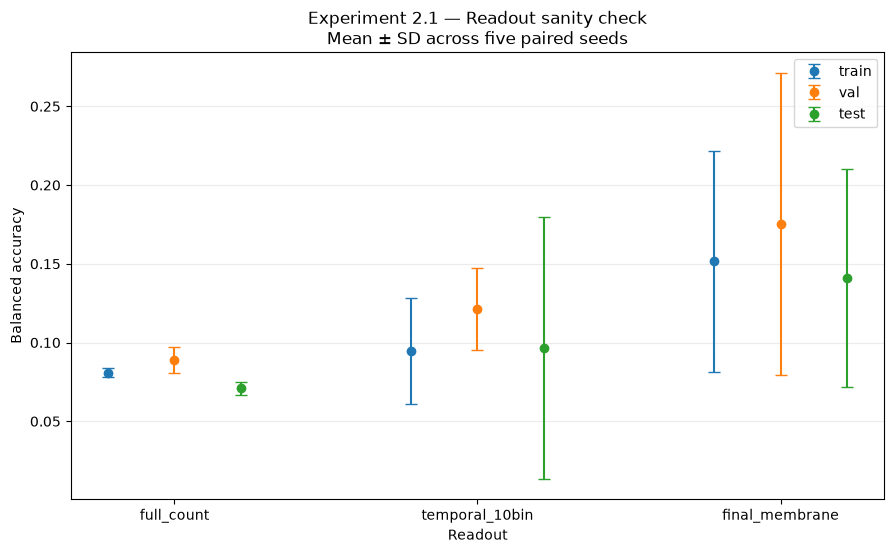

In [33]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))

x = np.arange(len(READOUTS), dtype=float)
offsets = {"train": -0.22, "val": 0.0, "test": 0.22}

for split_name in ("train", "val", "test"):
    means = []
    sds = []

    for readout in READOUTS:
        sdf = results[results.readout == readout]
        means.append(
            sdf[f"{split_name}_balanced_accuracy"].mean()
        )
        sds.append(
            sdf[f"{split_name}_balanced_accuracy"].std(ddof=1)
        )

    ax.errorbar(
        x + offsets[split_name],
        means,
        yerr=sds,
        marker="o",
        capsize=4,
        linestyle="none",
        label=split_name,
    )

ax.set_xticks(x, READOUTS)
ax.set_ylabel("Balanced accuracy")
ax.set_xlabel("Readout")
ax.set_title(
    "Experiment 2.1 — Readout sanity check\n"
    "Mean ± SD across five paired seeds"
)
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.show()


### 12.2 Seed-paired test balanced accuracy


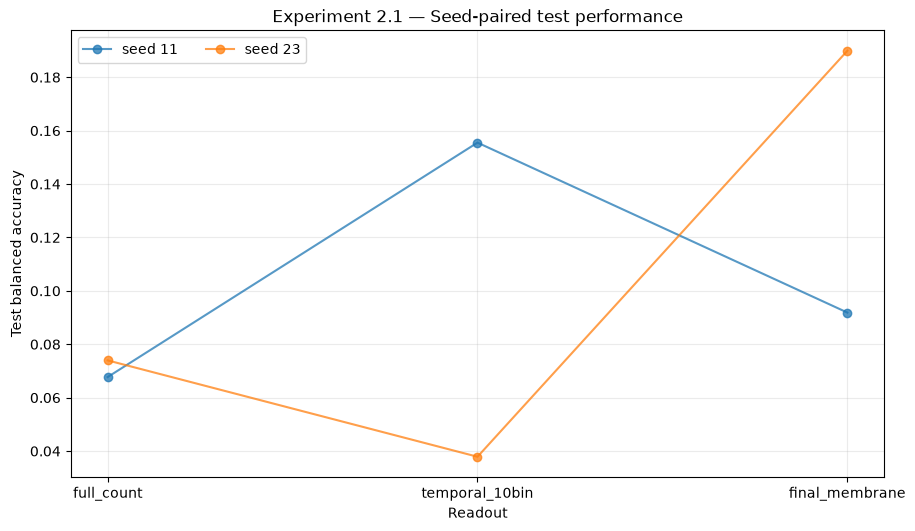

In [34]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))

for seed in SEEDS:
    sdf = results[results.seed == seed].copy()
    sdf["_order"] = sdf["readout"].map(order_map)
    sdf = sdf.sort_values("_order")

    ax.plot(
        np.arange(len(sdf)),
        sdf["test_balanced_accuracy"],
        marker="o",
        alpha=0.75,
        label=f"seed {seed}",
    )

ax.set_xticks(np.arange(len(READOUTS)), READOUTS)
ax.set_ylabel("Test balanced accuracy")
ax.set_xlabel("Readout")
ax.set_title("Experiment 2.1 — Seed-paired test performance")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.show()


### 12.3 Spike-activity diagnostics

A readout comparison is difficult to interpret if the fixed SNN is almost completely silent or saturated.


,readout,network_firing_rate,output_firing_rate,silent_output_fraction
1,full_count,0.425534,0.501353,0.0
2,temporal_10bin,0.398268,0.234518,0.0
0,final_membrane,0.422885,0.481069,0.0


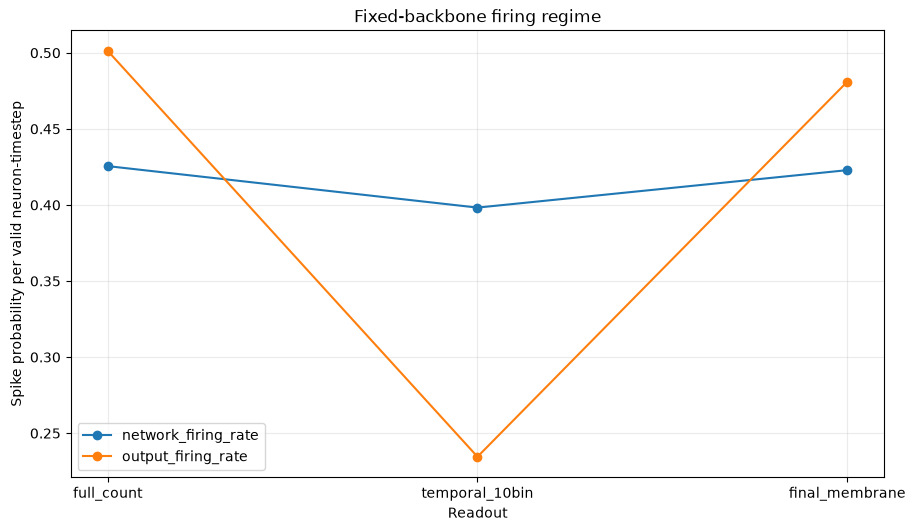

In [35]:
activity_summary = (
    results.groupby("readout", as_index=False)
    .agg(
        network_firing_rate=("test_network_firing_rate", "mean"),
        output_firing_rate=("test_output_firing_rate", "mean"),
        silent_output_fraction=("test_silent_output_fraction", "mean"),
    )
)
activity_summary["_order"] = activity_summary["readout"].map(order_map)
activity_summary = (
    activity_summary.sort_values("_order")
    .drop(columns="_order")
)

display(activity_summary)

fig, ax = plt.subplots(figsize=(10.5, 5.8))

for metric in ("network_firing_rate", "output_firing_rate"):
    ax.plot(
        activity_summary["readout"],
        activity_summary[metric],
        marker="o",
        label=metric,
    )

ax.set_ylabel("Spike probability per valid neuron-timestep")
ax.set_xlabel("Readout")
ax.set_title("Fixed-backbone firing regime")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


## 13. Save experiment provenance

The saved JSON records the scientific controls that must remain fixed when moving to Experiment 2.2.


In [36]:
provenance = {
    "experiment_id": EXPERIMENT_ID,
    "experiment_title": EXPERIMENT_TITLE,
    "dataset_roots": [
        str(Path(p).resolve())
        for p in DATASET_ROOTS
    ],
    "seeds": list(SEEDS),
    "included_labels": (
        None
        if INCLUDED_LABELS is None
        else list(map(str, INCLUDED_LABELS))
    ),
    "class_to_idx": CLASS_TO_IDX,
    "sampling_rate_hz": SAMPLING_RATE_HZ,
    "input_channels": INPUT_CHANNELS,
    "hidden_width": HIDDEN_WIDTH,
    "readouts": list(READOUTS),
    "n_temporal_bins": N_TEMPORAL_BINS,
    "tau_syn_ms": TAU_SYN_MS,
    "tau_mem_ms": TAU_MEM_MS,
    "alpha": ALPHA,
    "beta": BETA,
    "threshold": THRESHOLD,
    "surrogate_slope": SURROGATE_SLOPE,
    "reset_mechanism": RESET_MECHANISM,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "train_fraction": TRAIN_FRACTION,
    "val_fraction": VAL_FRACTION,
    "primary_selection_metric": "validation balanced accuracy",
    "primary_report_metric": "test balanced accuracy",
    "input_normalization": "none; direct weighted events preserved",
    "recurrence": False,
    "learn_alpha": False,
    "learn_beta": False,
    "learn_threshold": False,
}

with open(
    RESULTS_DIR / "experiment_2_1_provenance.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        provenance,
        f,
        indent=2,
        ensure_ascii=False,
    )

print("Saved artifacts to:", RESULTS_DIR)
for path in sorted(RESULTS_DIR.glob("experiment_2_1_*")):
    print(" -", path.name)


Saved artifacts to: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_2_1_snn_readout_sanity_check
 - experiment_2_1_paired_deltas.csv
 - experiment_2_1_provenance.json
 - experiment_2_1_results.csv
 - experiment_2_1_summary.csv
 - experiment_2_1_training_histories.csv


## Interpretation guide

Use **validation first**, then test as the final report.

### Outcome 1 — Temporal binning is much better

Example:

\[
BA_{full}\approx0.35,\qquad BA_{10bin}\approx0.60
\]

and the gain is positive across most/all seeds.

Interpretation:

\[
\boxed{\text{whole-sequence count is a readout bottleneck}}
\]

Use `temporal_10bin` as the control readout for Experiments 2.2 and 2.3. Do **not** conclude that a wider SNN is required from a weak full-count model.

### Outcome 2 — Full count and 10-bin are close

Example:

\[
0.58\quad\text{vs}\quad0.60
\]

with small paired deltas.

Interpretation:

\[
\boxed{\text{full count is adequate}}
\]

Prefer `full_count` for later capacity sweeps because it is simpler and adds no readout parameters.

### Outcome 3 — Every readout is weak and the network is nearly silent

Do **not** proceed directly to a width sweep. First check whether the fixed threshold / input scale / chosen single-\(\tau\) dynamics create an unusable firing regime.

### Outcome 4 — Train BA rises strongly but validation/test remain low

That is a capacity/generalization issue, not evidence that temporal binning solved the representation problem.

## What to freeze for Experiment 2.2

After 2.1, freeze:

- selected readout;
- `TAU_SYN_MS`;
- `TAU_MEM_MS`;
- threshold;
- surrogate gradient;
- reset mechanism;
- input representation;
- user-split protocol;
- optimizer/training settings.

Then vary **only width**.


## Review / audit checklist

Before treating Experiment 2.1 as evidence:

1. Confirm `DATASET_ROOTS` points to the intended combination root(s).
2. Confirm `paddedSpikeIMU[...,0:15]` is the intended encoder representation.
3. Confirm sampling-rate and encoder-identity validation passes.
4. Confirm the same five master seeds as Phase A are used.
5. Confirm train/validation/test users are disjoint for every seed.
6. Confirm alpha, beta, threshold are fixed and not learnable.
7. Confirm there are no recurrent connections.
8. Confirm the backbone is exactly `15 -> 64 -> 64 -> K`.
9. Confirm all three readouts share the same split, DataLoader seed, and backbone initialization seed within each master seed.
10. Inspect `readout_params`: only `temporal_10bin` should add classifier parameters.
11. Inspect spike activity; an almost-silent fixed SNN invalidates a simple readout conclusion.
12. Select the Experiment-2.2 readout using validation behavior and seed consistency, not a single test result.
